In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

import optuna

import warnings
warnings.filterwarnings('ignore')

In [6]:
import pandas as pd
import numpy as np

# Load cleaned dataset
df = pd.read_csv(
    r"C:\Users\HP\Desktop\retailpulse_project\data\processed\cleaned_data.csv"
)

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reference date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Create churn label
rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)

rfm.head()

,Recency,Frequency,Monetary,Churn
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [7]:
rfm['Churn'].value_counts()

Churn
0    2889
1    1449
Name: count, dtype: int64

In [8]:
# train - test split

from sklearn.model_selection import train_test_split

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (3470, 3)
Test Shape: (868, 3)


In [9]:
#Train Baseline XGBoost Model


from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       578
           1       1.00      1.00      1.00       290

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [10]:
baseline_accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 1.0


In [11]:
# optuna tuning



import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)

    return accuracy

In [12]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=20)

print("Best Accuracy:", study.best_value)
print("\nBest Parameters:")
print(study.best_params)

[I 2026-06-17 12:49:27,330] A new study created in memory with name: no-name-343df64b-ab0d-4e1d-aec5-3402bb1969e8
[I 2026-06-17 12:49:27,906] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 186, 'max_depth': 3, 'learning_rate': 0.26804508444320274, 'subsample': 0.7965446559738238, 'colsample_bytree': 0.6017486890314411}. Best is trial 0 with value: 1.0.
[I 2026-06-17 12:49:29,001] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 252, 'max_depth': 3, 'learning_rate': 0.17388264116971103, 'subsample': 0.6646184111555303, 'colsample_bytree': 0.7185710307070508}. Best is trial 0 with value: 1.0.
[I 2026-06-17 12:49:29,307] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 204, 'max_depth': 10, 'learning_rate': 0.2344975781508449, 'subsample': 0.7420451785166058, 'colsample_bytree': 0.9177691139446839}. Best is trial 0 with value: 1.0.
[I 2026-06-17 12:49:29,553] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 120, 'max_de

Best Accuracy: 1.0

Best Parameters:
{'n_estimators': 186, 'max_depth': 3, 'learning_rate': 0.26804508444320274, 'subsample': 0.7965446559738238, 'colsample_bytree': 0.6017486890314411}


In [13]:
study.best_value

1.0

In [14]:
study.best_params

{'n_estimators': 186,
 'max_depth': 3,
 'learning_rate': 0.26804508444320274,
 'subsample': 0.7965446559738238,
 'colsample_bytree': 0.6017486890314411}

In [15]:
# feature importance analysis

best_model = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric="logloss"
)

best_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.6017486890314411
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


<Figure size 800x500 with 0 Axes>

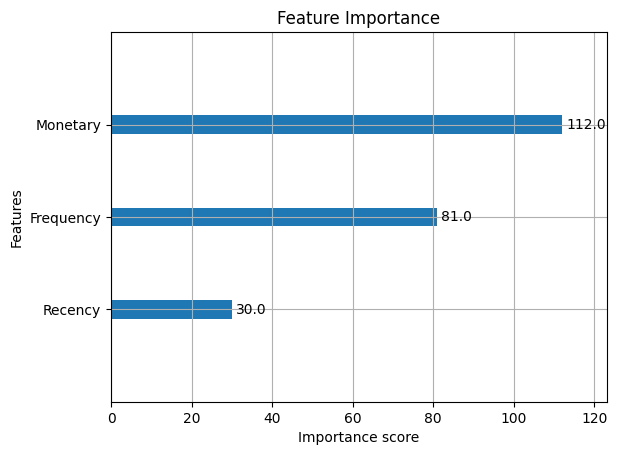

In [17]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(8,5))
plot_importance(best_model)
plt.title("Feature Importance")
plt.show()

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Recency,0.947052
2,Monetary,0.034241
1,Frequency,0.018706


In [20]:
feature_importance.to_csv(
    r"C:\Users\HP\Desktop\retailpulse_project\reports\tuning_results\feature_importance.csv",
    index=False
)



In [22]:
best_params_df = pd.DataFrame([study.best_params])

best_params_df.to_csv(
    r"C:\Users\HP\Desktop\retailpulse_project\reports\tuning_results\best_parameters.csv",
    index=False
)



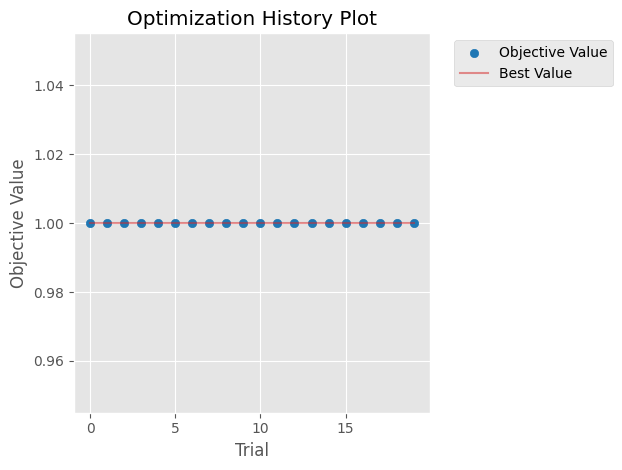

In [23]:
optuna.visualization.matplotlib.plot_optimization_history(study)

plt.tight_layout()

plt.savefig(
    r"C:\Users\HP\Desktop\retailpulse_project\reports\tuning_results\optimization_history.png"
)

plt.show()